# 04 Baseline Clustering

This notebook creates the first baseline clustering experiments for the customer segmentation project. It compares two approved feature sets with K-Means across several values of `k`.

This is not the final clustering notebook. It does not select a final model and does not create a final customer-cluster CSV.


## Purpose of this notebook

The previous notebook reviewed the engineered features and defined two baseline feature sets. This notebook tests those feature sets with a simple, explainable clustering algorithm so we can see how different `k` values behave.

The goal is to compare options, not to finalize the segmentation.


## Setup and data loading

This section imports the required libraries, locates the project root, and loads the raw datasets using the existing project helpers. The fixed reference date keeps age and tenure reproducible.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    PLOTS_AVAILABLE = True
except ImportError:
    plt = None
    PLOTS_AVAILABLE = False

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        if hasattr(obj, "to_string"):
            print(obj.to_string())
        else:
            print(obj)


def has_raw_datasets(candidate):
    root_layout = (candidate / "customer_info.csv").exists() and (candidate / "customer_basket.csv").exists()
    project_files_layout = (candidate / "Project files" / "customer_info.csv").exists() and (candidate / "Project files" / "customer_basket.csv").exists()
    return root_layout or project_files_layout


def find_project_root(start):
    for candidate in [start, *start.parents]:
        if has_raw_datasets(candidate):
            return candidate
    raise FileNotFoundError("Could not locate raw datasets at the repository root or in Project files/.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

REFERENCE_DATE = pd.Timestamp("2026-05-30")
RANDOM_STATE = 42
K_VALUES = list(range(2, 11))
SILHOUETTE_SAMPLE_SIZE = 5000

print(f"Project root: {PROJECT_ROOT}")
print(f"Reference date for age and tenure: {REFERENCE_DATE.date()}")
print(f"Random state: {RANDOM_STATE}")
print(f"K values: {K_VALUES}")
print(f"Matplotlib available for plots: {PLOTS_AVAILABLE}")


Project root: C:\Users\pedro\Desktop\ML-II-projeto-final
Reference date for age and tenure: 2026-05-30
Random state: 42
K values: [2, 3, 4, 5, 6, 7, 8, 9, 10]
Matplotlib available for plots: True


In [2]:
from src.data_loading import load_datasets
from src.features import build_customer_feature_table


In [3]:
customer_info, customer_basket = load_datasets(PROJECT_ROOT)

print(f"customer_info rows: {len(customer_info):,}")
print(f"unique customers in customer_info: {customer_info['customer_id'].nunique():,}")
print(f"customer_basket rows: {len(customer_basket):,}")


customer_info rows: 33,038
unique customers in customer_info: 33,038
customer_basket rows: 100,000


## Build and validate feature table

The feature table is rebuilt with the existing project workflow. Before modeling, the notebook checks that the table is complete and that no final clustering output already exists.


In [4]:
feature_table, metadata = build_customer_feature_table(
    customer_info,
    customer_basket,
    reference_date=REFERENCE_DATE,
)

print(f"feature table shape: {feature_table.shape}")
print(f"output customer count: {metadata['output_customer_count']:,}")
print(f"basket parse errors: {metadata['basket_parse_errors']}")
print(f"customers without sampled baskets: {metadata['customers_without_baskets']:,}")


feature table shape: (33038, 77)
output customer count: 33,038
basket parse errors: 0
customers without sampled baskets: 4,911


In [5]:
outputs_dir = PROJECT_ROOT / "outputs"
final_output_files = []
if outputs_dir.exists():
    for path in outputs_dir.iterdir():
        name = path.name.lower()
        looks_like_final_cluster_output = path.suffix.lower() == ".csv" and (
            "cluster" in name or "segment" in name
        )
        if path.is_file() and looks_like_final_cluster_output:
            final_output_files.append(path.name)

initial_validation = pd.DataFrame(
    [
        {"check": "feature table shape is 33038 x 77", "value": str(feature_table.shape), "passes": feature_table.shape == (33038, 77)},
        {"check": "customer_id is unique", "value": feature_table["customer_id"].is_unique, "passes": feature_table["customer_id"].is_unique},
        {"check": "feature table has no missing values", "value": int(feature_table.isna().sum().sum()), "passes": int(feature_table.isna().sum().sum()) == 0},
        {"check": "customer_name is not present", "value": "customer_name" in feature_table.columns, "passes": "customer_name" not in feature_table.columns},
        {"check": "no final clustering csv outputs", "value": final_output_files, "passes": len(final_output_files) == 0},
    ]
)

display(initial_validation)
assert initial_validation["passes"].all()


,check,value,passes
0,feature table shape is 33038 x 77,"(33038, 77)",True
1,customer_id is unique,True,True
2,feature table has no missing values,0,True
3,customer_name is not present,False,True
4,no final clustering csv outputs,[],True


## Define baseline feature sets

The two feature sets come from the approved feature review.

Baseline A uses customer-info-derived behavior only and excludes basket features.

Baseline B starts from Baseline A and adds only the reduced basket set: `has_sampled_basket`, `basket_count`, and `avg_basket_size`.

The first baseline intentionally excludes `customer_id`, raw identifiers, raw lifetime spend category amounts, gender, degree, location, `typical_hour`, data-quality flags, missingness flags, and `unique_basket_products`.


In [6]:
def existing(columns):
    # Keep only columns available in the current feature table.
    return [column for column in columns if column in feature_table.columns]

spend_share_columns = [column for column in feature_table.columns if column.startswith("spend_share_")]

model_features_a_no_basket = existing(
    [
        "customer_age",
        "customer_tenure_years",
        "kids_home",
        "teens_home",
        "distinct_stores_visited",
        "lifetime_total_distinct_products",
        "has_loyalty_card",
        "number_complaints",
        "promotion_pct_clean",
        "total_lifetime_spend",
        *spend_share_columns,
    ]
)

reduced_basket_features = ["has_sampled_basket", "basket_count", "avg_basket_size"]
model_features_b_with_basket = model_features_a_no_basket + existing(reduced_basket_features)

all_basket_feature_columns = [
    "has_sampled_basket",
    "basket_count",
    "avg_basket_size",
    "median_basket_size",
    "max_basket_size",
    "total_basket_items",
    "unique_basket_products",
]

raw_lifetime_spend_columns = [
    column for column in feature_table.columns
    if column.startswith("lifetime_spend_") and not column.endswith("_was_missing")
]

excluded_feature_candidates = [
    "customer_id",
    "customer_name",
    "customer_birthdate",
    "customer_birthdate_parsed",
    "loyalty_card_number",
    "year_first_transaction",
    "first_transaction_year_clean",
    "percentage_of_products_bought_promotion",
    "list_of_goods",
    *raw_lifetime_spend_columns,
]
excluded_features = existing(excluded_feature_candidates)

feature_set_summary = pd.DataFrame(
    [
        {"feature_set": "Baseline A - no basket", "feature_count": len(model_features_a_no_basket), "features": ", ".join(model_features_a_no_basket)},
        {"feature_set": "Baseline B - reduced basket", "feature_count": len(model_features_b_with_basket), "features": ", ".join(model_features_b_with_basket)},
        {"feature_set": "excluded features present", "feature_count": len(excluded_features), "features": ", ".join(excluded_features)},
    ]
)

display(feature_set_summary)


,feature_set,feature_count,features
0,Baseline A - no basket,20,"customer_age, customer_tenure_years, kids_home..."
1,Baseline B - reduced basket,23,"customer_age, customer_tenure_years, kids_home..."
2,excluded features present,11,"customer_id, lifetime_spend_groceries, lifetim..."


In [7]:
feature_set_validation = pd.DataFrame(
    [
        {"check": "all Baseline A features exist", "value": len(model_features_a_no_basket), "passes": all(column in feature_table.columns for column in model_features_a_no_basket)},
        {"check": "all Baseline B features exist", "value": len(model_features_b_with_basket), "passes": all(column in feature_table.columns for column in model_features_b_with_basket)},
        {"check": "no basket features in Baseline A", "value": sorted(set(model_features_a_no_basket) & set(all_basket_feature_columns)), "passes": set(model_features_a_no_basket).isdisjoint(all_basket_feature_columns)},
        {"check": "Baseline B contains only reduced basket features", "value": sorted(set(model_features_b_with_basket) & set(all_basket_feature_columns)), "passes": set(model_features_b_with_basket) & set(all_basket_feature_columns) == set(reduced_basket_features)},
        {"check": "customer_id excluded from Baseline A", "value": "customer_id" in model_features_a_no_basket, "passes": "customer_id" not in model_features_a_no_basket},
        {"check": "customer_id excluded from Baseline B", "value": "customer_id" in model_features_b_with_basket, "passes": "customer_id" not in model_features_b_with_basket},
        {"check": "excluded features are not modeled", "value": sorted(set(excluded_features) & set(model_features_a_no_basket + model_features_b_with_basket)), "passes": set(excluded_features).isdisjoint(model_features_a_no_basket + model_features_b_with_basket)},
        {"check": "unique_basket_products excluded from Baseline B", "value": "unique_basket_products" in model_features_b_with_basket, "passes": "unique_basket_products" not in model_features_b_with_basket},
    ]
)

display(feature_set_validation)
assert feature_set_validation["passes"].all()


,check,value,passes
0,all Baseline A features exist,20,True
1,all Baseline B features exist,23,True
2,no basket features in Baseline A,[],True
3,Baseline B contains only reduced basket features,"[avg_basket_size, basket_count, has_sampled_ba...",True
4,customer_id excluded from Baseline A,False,True
5,customer_id excluded from Baseline B,False,True
6,excluded features are not modeled,[],True
7,unique_basket_products excluded from Baseline B,False,True


## Prepare modeling matrices

The modeling matrices contain only the selected features. `customer_id` stays outside the matrix so it can be used later for joining or reporting without influencing clustering.


In [8]:
X_a_raw = feature_table[model_features_a_no_basket].copy()
X_b_raw = feature_table[model_features_b_with_basket].copy()

matrix_summary = pd.DataFrame(
    [
        {"matrix": "X_a_raw", "rows": X_a_raw.shape[0], "columns": X_a_raw.shape[1], "missing_values": int(X_a_raw.isna().sum().sum())},
        {"matrix": "X_b_raw", "rows": X_b_raw.shape[0], "columns": X_b_raw.shape[1], "missing_values": int(X_b_raw.isna().sum().sum())},
    ]
)

display(matrix_summary)


,matrix,rows,columns,missing_values
0,X_a_raw,33038,20,0
1,X_b_raw,33038,23,0


## Transform skewed variables

K-Means uses distances, so very skewed variables can dominate the solution. The first baseline applies simple `log1p` transformations to selected count or spend variables while keeping feature names understandable.


In [9]:
def transform_modeling_matrix(matrix):
    transformed = matrix.copy()

    if "total_lifetime_spend" in transformed.columns:
        transformed["log_total_lifetime_spend"] = np.log1p(transformed["total_lifetime_spend"])
        transformed = transformed.drop(columns=["total_lifetime_spend"])

    if "basket_count" in transformed.columns:
        transformed["log_basket_count"] = np.log1p(transformed["basket_count"])
        transformed = transformed.drop(columns=["basket_count"])

    return transformed

X_a_transformed = transform_modeling_matrix(X_a_raw)
X_b_transformed = transform_modeling_matrix(X_b_raw)

transformed_summary = pd.DataFrame(
    [
        {"matrix": "X_a_transformed", "rows": X_a_transformed.shape[0], "columns": X_a_transformed.shape[1], "missing_values": int(X_a_transformed.isna().sum().sum()), "example_columns": ", ".join(X_a_transformed.columns[:8])},
        {"matrix": "X_b_transformed", "rows": X_b_transformed.shape[0], "columns": X_b_transformed.shape[1], "missing_values": int(X_b_transformed.isna().sum().sum()), "example_columns": ", ".join(X_b_transformed.columns[:8])},
    ]
)

display(transformed_summary)


,matrix,rows,columns,missing_values,example_columns
0,X_a_transformed,33038,20,0,"customer_age, customer_tenure_years, kids_home..."
1,X_b_transformed,33038,23,0,"customer_age, customer_tenure_years, kids_home..."


## Scale features

Standard scaling gives each feature comparable influence in distance-based clustering. The scaler is fit separately for each baseline feature set.


In [10]:
scaler_a = StandardScaler()
scaler_b = StandardScaler()

X_a_scaled = scaler_a.fit_transform(X_a_transformed)
X_b_scaled = scaler_b.fit_transform(X_b_transformed)

scaled_validation = pd.DataFrame(
    [
        {"matrix": "X_a_scaled", "rows": X_a_scaled.shape[0], "columns": X_a_scaled.shape[1], "missing_values": int(np.isnan(X_a_scaled).sum())},
        {"matrix": "X_b_scaled", "rows": X_b_scaled.shape[0], "columns": X_b_scaled.shape[1], "missing_values": int(np.isnan(X_b_scaled).sum())},
    ]
)

display(scaled_validation)
assert X_a_scaled.shape[0] == len(feature_table)
assert X_b_scaled.shape[0] == len(feature_table)
assert int(np.isnan(X_a_scaled).sum()) == 0
assert int(np.isnan(X_b_scaled).sum()) == 0


,matrix,rows,columns,missing_values
0,X_a_scaled,33038,20,0
1,X_b_scaled,33038,23,0


## Train K-Means baseline models

This section trains K-Means for `k = 2` through `k = 10` for both baseline feature sets. These are baseline experiments only. The notebook records metrics and cluster sizes, but it does not select a final model.


In [11]:
def evaluate_kmeans(feature_set_name, scaled_matrix):
    result_rows = []
    cluster_size_rows = []
    labels_by_k = {}

    for k in K_VALUES:
        model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = model.fit_predict(scaled_matrix)
        labels_by_k[k] = labels

        counts = pd.Series(labels).value_counts().sort_index()
        silhouette = silhouette_score(
            scaled_matrix,
            labels,
            sample_size=min(SILHOUETTE_SAMPLE_SIZE, scaled_matrix.shape[0]),
            random_state=RANDOM_STATE,
        )

        result_rows.append(
            {
                "feature_set": feature_set_name,
                "k": k,
                "inertia": float(model.inertia_),
                "silhouette_score": float(silhouette),
                "cluster_count": int(len(counts)),
                "smallest_cluster_size": int(counts.min()),
                "largest_cluster_size": int(counts.max()),
                "smallest_cluster_percentage": float(counts.min() / len(labels)),
                "largest_cluster_percentage": float(counts.max() / len(labels)),
            }
        )

        for cluster_id, cluster_size in counts.items():
            cluster_size_rows.append(
                {
                    "feature_set": feature_set_name,
                    "k": k,
                    "cluster": int(cluster_id),
                    "cluster_size": int(cluster_size),
                    "cluster_percentage": float(cluster_size / len(labels)),
                }
            )

    return pd.DataFrame(result_rows), pd.DataFrame(cluster_size_rows), labels_by_k

results_a, cluster_sizes_a, labels_a = evaluate_kmeans("Baseline A - no basket", X_a_scaled)
results_b, cluster_sizes_b, labels_b = evaluate_kmeans("Baseline B - reduced basket", X_b_scaled)

model_results = pd.concat([results_a, results_b], ignore_index=True)
cluster_size_summary = pd.concat([cluster_sizes_a, cluster_sizes_b], ignore_index=True)
labels_by_feature_set = {
    "Baseline A - no basket": labels_a,
    "Baseline B - reduced basket": labels_b,
}

model_results_display = model_results.copy()
model_results_display["inertia"] = model_results_display["inertia"].round(2)
model_results_display["silhouette_score"] = model_results_display["silhouette_score"].round(4)
model_results_display["smallest_cluster_percentage"] = (model_results_display["smallest_cluster_percentage"] * 100).round(2)
model_results_display["largest_cluster_percentage"] = (model_results_display["largest_cluster_percentage"] * 100).round(2)

display(model_results_display)


,feature_set,k,inertia,silhouette_score,cluster_count,smallest_cluster_size,largest_cluster_size,smallest_cluster_percentage,largest_cluster_percentage
0,Baseline A - no basket,2,577417.81,0.2146,2,8009,25029,24.24,75.76
1,Baseline A - no basket,3,526699.25,0.1365,3,6062,20791,18.35,62.93
2,Baseline A - no basket,4,483290.07,0.1299,4,4661,11962,14.11,36.21
3,Baseline A - no basket,5,448624.01,0.1413,5,2142,11294,6.48,34.18
4,Baseline A - no basket,6,418639.09,0.1417,6,1989,11156,6.02,33.77
5,Baseline A - no basket,7,401107.83,0.1416,7,1830,10791,5.54,32.66
6,Baseline A - no basket,8,385045.19,0.1245,8,1808,7147,5.47,21.63
7,Baseline A - no basket,9,370785.41,0.1273,9,1469,6340,4.45,19.19
8,Baseline A - no basket,10,361089.46,0.1297,10,1462,5250,4.43,15.89
9,Baseline B - reduced basket,2,676467.13,0.1904,2,8126,24912,24.60,75.40


## Compare k values

The elbow plot uses inertia, while the silhouette line chart shows separation quality. These plots help narrow down candidates, but they do not choose the final model by themselves.


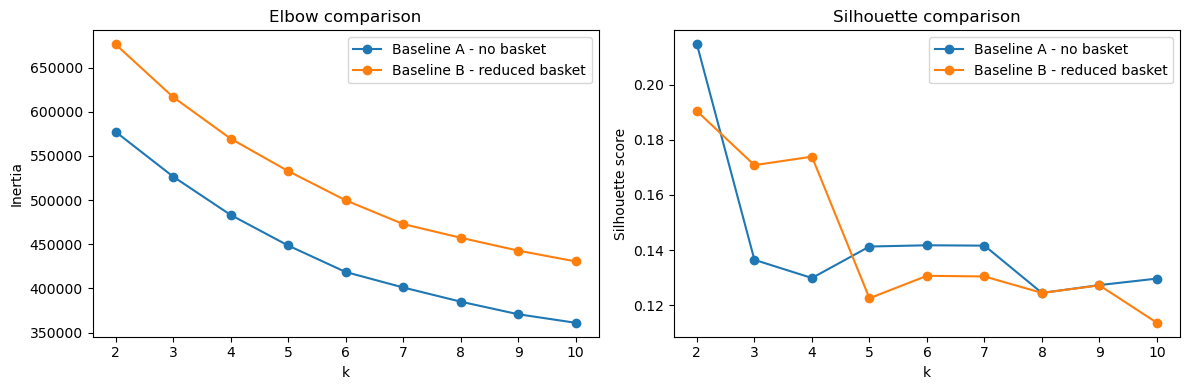

In [12]:
if PLOTS_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for feature_set, group in model_results.groupby("feature_set"):
        axes[0].plot(group["k"], group["inertia"], marker="o", label=feature_set)
        axes[1].plot(group["k"], group["silhouette_score"], marker="o", label=feature_set)

    axes[0].set_title("Elbow comparison")
    axes[0].set_xlabel("k")
    axes[0].set_ylabel("Inertia")
    axes[0].legend()

    axes[1].set_title("Silhouette comparison")
    axes[1].set_xlabel("k")
    axes[1].set_ylabel("Silhouette score")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("Plots skipped because matplotlib is not available in this environment.")


## Compare Baseline A vs Baseline B

Baseline B adds basket availability and basket-size behavior. This comparison checks whether the basket features improve the metrics or risk making clusters mainly about whether sampled basket data exists.


In [13]:
best_by_silhouette = model_results.sort_values("silhouette_score", ascending=False).groupby("feature_set").head(3).copy()
best_by_silhouette_display = best_by_silhouette.copy()
best_by_silhouette_display["inertia"] = best_by_silhouette_display["inertia"].round(2)
best_by_silhouette_display["silhouette_score"] = best_by_silhouette_display["silhouette_score"].round(4)
best_by_silhouette_display["smallest_cluster_percentage"] = (best_by_silhouette_display["smallest_cluster_percentage"] * 100).round(2)
best_by_silhouette_display["largest_cluster_percentage"] = (best_by_silhouette_display["largest_cluster_percentage"] * 100).round(2)

display(best_by_silhouette_display)

promising_keys = set(zip(best_by_silhouette["feature_set"], best_by_silhouette["k"]))
promising_cluster_sizes = cluster_size_summary[
    cluster_size_summary.apply(lambda row: (row["feature_set"], row["k"]) in promising_keys, axis=1)
].copy()
promising_cluster_sizes["cluster_percentage"] = (promising_cluster_sizes["cluster_percentage"] * 100).round(2)

display(promising_cluster_sizes)


,feature_set,k,inertia,silhouette_score,cluster_count,smallest_cluster_size,largest_cluster_size,smallest_cluster_percentage,largest_cluster_percentage
0,Baseline A - no basket,2,577417.81,0.2146,2,8009,25029,24.24,75.76
9,Baseline B - reduced basket,2,676467.13,0.1904,2,8126,24912,24.60,75.40
11,Baseline B - reduced basket,4,569651.95,0.1739,4,3495,20203,10.58,61.15
10,Baseline B - reduced basket,3,616754.81,0.1708,3,4607,21650,13.94,65.53
4,Baseline A - no basket,6,418639.09,0.1417,6,1989,11156,6.02,33.77
5,Baseline A - no basket,7,401107.83,0.1416,7,1830,10791,5.54,32.66


,feature_set,k,cluster,cluster_size,cluster_percentage
0,Baseline A - no basket,2,0,8009,24.24
1,Baseline A - no basket,2,1,25029,75.76
14,Baseline A - no basket,6,0,1989,6.02
15,Baseline A - no basket,6,1,11156,33.77
16,Baseline A - no basket,6,2,7813,23.65
17,Baseline A - no basket,6,3,3331,10.08
18,Baseline A - no basket,6,4,5703,17.26
19,Baseline A - no basket,6,5,3046,9.22
20,Baseline A - no basket,7,0,3289,9.96
21,Baseline A - no basket,7,1,4046,12.25


## Preliminary interpretation checks

These checks are diagnostic only. They help identify risks such as a basket-based solution being dominated by `has_sampled_basket`. They do not make the clustering final.


In [14]:
best_a_k = int(model_results[model_results["feature_set"] == "Baseline A - no basket"].sort_values("silhouette_score", ascending=False).iloc[0]["k"])
best_b_k = int(model_results[model_results["feature_set"] == "Baseline B - reduced basket"].sort_values("silhouette_score", ascending=False).iloc[0]["k"])

feature_table_with_best_b = feature_table[["customer_id", "has_sampled_basket", "basket_count", "avg_basket_size", "total_lifetime_spend"]].copy()
feature_table_with_best_b["baseline_b_cluster"] = labels_by_feature_set["Baseline B - reduced basket"][best_b_k]

baseline_b_basket_profile = feature_table_with_best_b.groupby("baseline_b_cluster").agg(
    customers=("customer_id", "count"),
    sampled_basket_share=("has_sampled_basket", "mean"),
    avg_basket_count=("basket_count", "mean"),
    avg_basket_size=("avg_basket_size", "mean"),
    avg_total_lifetime_spend=("total_lifetime_spend", "mean"),
).reset_index()

baseline_b_basket_profile["customer_percentage"] = baseline_b_basket_profile["customers"] / len(feature_table) * 100
baseline_b_basket_profile = baseline_b_basket_profile.round(3)

print(f"Best silhouette k for Baseline A: {best_a_k}")
print(f"Best silhouette k for Baseline B: {best_b_k}")
print("Baseline B basket-availability diagnostic profile")
display(baseline_b_basket_profile)


Best silhouette k for Baseline A: 2
Best silhouette k for Baseline B: 2
Baseline B basket-availability diagnostic profile


,baseline_b_cluster,customers,sampled_basket_share,avg_basket_count,avg_basket_size,avg_total_lifetime_spend,customer_percentage
0,0,24912,0.856,3.089,8.071,26164.981,75.404
1,1,8126,0.838,2.837,7.677,16168.424,24.596


## Preliminary candidate discussion

No final model is selected here. A candidate should be judged using several signals together:

- Higher silhouette scores suggest better separation, but should not be the only criterion.
- Inertia should show a reasonable elbow rather than only improving mechanically as `k` increases.
- Cluster sizes should be balanced enough to interpret and defend.
- Baseline B should be checked for over-reliance on basket availability because basket data is sampled.
- The final choice should also be easy to explain in business/customer terms.


In [15]:
preliminary_notes = pd.DataFrame(
    [
        {"criterion": "silhouette_score", "how_to_use": "Prefer candidates with stronger separation, but avoid choosing only by this metric."},
        {"criterion": "inertia/elbow", "how_to_use": "Look for a point where adding more clusters gives smaller improvements."},
        {"criterion": "cluster balance", "how_to_use": "Avoid candidates with extremely tiny or overly dominant clusters unless there is a clear interpretation."},
        {"criterion": "Baseline B risk", "how_to_use": "Check whether clusters mainly split customers by has_sampled_basket instead of broader behavior."},
        {"criterion": "interpretability", "how_to_use": "Prefer a solution that can be explained with customer behavior and spend patterns."},
    ]
)

display(preliminary_notes)


,criterion,how_to_use
0,silhouette_score,"Prefer candidates with stronger separation, bu..."
1,inertia/elbow,Look for a point where adding more clusters gi...
2,cluster balance,Avoid candidates with extremely tiny or overly...
3,Baseline B risk,Check whether clusters mainly split customers ...
4,interpretability,Prefer a solution that can be explained with c...


## Final validation checks

The final checks confirm that the notebook trained only baseline comparison models, kept `customer_id` out of the modeling matrices, and did not create final clustering outputs.


In [16]:
outputs_dir = PROJECT_ROOT / "outputs"
final_output_files = []
if outputs_dir.exists():
    for path in outputs_dir.iterdir():
        name = path.name.lower()
        looks_like_final_cluster_output = path.suffix.lower() == ".csv" and (
            "cluster" in name or "segment" in name
        )
        if path.is_file() and looks_like_final_cluster_output:
            final_output_files.append(path.name)

final_validation = pd.DataFrame(
    [
        {"check": "feature table shape remains 33038 x 77", "value": str(feature_table.shape), "passes": feature_table.shape == (33038, 77)},
        {"check": "customer_id is unique", "value": feature_table["customer_id"].is_unique, "passes": feature_table["customer_id"].is_unique},
        {"check": "feature table has no missing values", "value": int(feature_table.isna().sum().sum()), "passes": int(feature_table.isna().sum().sum()) == 0},
        {"check": "Baseline A has no basket features", "value": sorted(set(model_features_a_no_basket) & set(all_basket_feature_columns)), "passes": set(model_features_a_no_basket).isdisjoint(all_basket_feature_columns)},
        {"check": "Baseline B has only reduced basket features", "value": sorted(set(model_features_b_with_basket) & set(all_basket_feature_columns)), "passes": set(model_features_b_with_basket) & set(all_basket_feature_columns) == set(reduced_basket_features)},
        {"check": "RANDOM_STATE is 42", "value": RANDOM_STATE, "passes": RANDOM_STATE == 42},
        {"check": "k values 2 through 10 evaluated", "value": sorted(model_results["k"].unique().tolist()), "passes": sorted(model_results["k"].unique().tolist()) == K_VALUES},
        {"check": "model comparison table exists", "value": model_results.shape, "passes": len(model_results) == len(K_VALUES) * 2},
        {"check": "cluster-size summaries exist", "value": cluster_size_summary.shape, "passes": len(cluster_size_summary) > 0},
        {"check": "X_a rows match feature table", "value": X_a_scaled.shape[0], "passes": X_a_scaled.shape[0] == len(feature_table)},
        {"check": "X_b rows match feature table", "value": X_b_scaled.shape[0], "passes": X_b_scaled.shape[0] == len(feature_table)},
        {"check": "X_a has no missing values", "value": int(np.isnan(X_a_scaled).sum()), "passes": int(np.isnan(X_a_scaled).sum()) == 0},
        {"check": "X_b has no missing values", "value": int(np.isnan(X_b_scaled).sum()), "passes": int(np.isnan(X_b_scaled).sum()) == 0},
        {"check": "customer_id excluded from Baseline A", "value": "customer_id" in model_features_a_no_basket, "passes": "customer_id" not in model_features_a_no_basket},
        {"check": "customer_id excluded from Baseline B", "value": "customer_id" in model_features_b_with_basket, "passes": "customer_id" not in model_features_b_with_basket},
        {"check": "no final clustering csv outputs", "value": final_output_files, "passes": len(final_output_files) == 0},
    ]
)

display(final_validation)
assert final_validation["passes"].all()
print("Baseline clustering validation passed. No final model was selected and no final cluster CSV was created.")


,check,value,passes
0,feature table shape remains 33038 x 77,"(33038, 77)",True
1,customer_id is unique,True,True
2,feature table has no missing values,0,True
3,Baseline A has no basket features,[],True
4,Baseline B has only reduced basket features,"[avg_basket_size, basket_count, has_sampled_ba...",True
5,RANDOM_STATE is 42,42,True
6,k values 2 through 10 evaluated,"[2, 3, 4, 5, 6, 7, 8, 9, 10]",True
7,model comparison table exists,"(18, 9)",True
8,cluster-size summaries exist,"(108, 5)",True
9,X_a rows match feature table,33038,True


Baseline clustering validation passed. No final model was selected and no final cluster CSV was created.


## Summary and next recommended task

This notebook trained baseline K-Means models for Baseline A and Baseline B across `k = 2` through `k = 10`. It created comparison metrics and cluster-size summaries, but it did not select a final model.

The next task should review these results, choose a small number of candidate configurations to interpret in detail, and decide whether Baseline A or Baseline B is more appropriate before creating any final customer-cluster output.


In [17]:
summary = pd.DataFrame(
    [
        {"topic": "feature table", "finding": "33,038 customers and 77 columns were used for baseline clustering experiments."},
        {"topic": "Baseline A", "finding": f"Evaluated {len(K_VALUES)} K-Means models using {len(model_features_a_no_basket)} non-basket features."},
        {"topic": "Baseline B", "finding": f"Evaluated {len(K_VALUES)} K-Means models using {len(model_features_b_with_basket)} features, including the reduced basket set."},
        {"topic": "status", "finding": "No final model has been selected."},
        {"topic": "outputs", "finding": "No final customer-cluster CSV was created."},
        {"topic": "next task", "finding": "Interpret the most promising candidates and decide which configuration should move toward final segmentation."},
    ]
)

display(summary)


,topic,finding
0,feature table,"33,038 customers and 77 columns were used for ..."
1,Baseline A,Evaluated 9 K-Means models using 20 non-basket...
2,Baseline B,"Evaluated 9 K-Means models using 23 features, ..."
3,status,No final model has been selected.
4,outputs,No final customer-cluster CSV was created.
5,next task,Interpret the most promising candidates and de...
